In [1]:
from pathlib import Path
import sys

from mpi4py import MPI
import numpy as np

from dolfinx import fem, geometry
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, create_vector
import ufl
from petsc4py import PETSc

from matplotlib import pyplot as plt

# Support running the notebook from either the repository root or Nagumo/.
cwd = Path.cwd().resolve()
if (cwd / "Nagumo").is_dir() and (cwd / "mesh_generator.py").is_file():
    project_root = cwd
elif cwd.name == "Nagumo" and (cwd.parent / "mesh_generator.py").is_file():
    project_root = cwd.parent
else:
    raise RuntimeError("Run this notebook from the repository root or Nagumo directory")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from FEM_functions import plot_solution
from mesh_generator import generate_disk_with_hole_mesh


In [2]:
# ----------------------------------------------------------------------
# 1. Parameters
# ----------------------------------------------------------------------
from Nagumo.params import (
    A0,
    T,
    a1,
    a2,
    alpha,
    dt,
    h,
    hole_r,
    hole_x,
    hole_y,
    mesh_filename,
    num_steps,
    sigma0,
    x0,
    y0,
)

print(f"Target mesh size h = {h:.4f}  =>  expected vertices ~ {1 / h**2:.0f}")
print(f"Time step dt = {dt:.4f}  =>  number of steps = {num_steps}")


Target mesh size h = 0.0250  =>  expected vertices ~ 1600
Time step dt = 0.0050  =>  number of steps = 1000


In [3]:
# ----------------------------------------------------------------------
# 2. Mesh: unit disk with a circular hole via Gmsh
# ----------------------------------------------------------------------
mesh_comm = MPI.COMM_WORLD
model_rank = 0
mesh_path = project_root / "Nagumo" / mesh_filename

domain = generate_disk_with_hole_mesh(
    mesh_comm,
    model_rank,
    mesh_size=h,
    hole_center=(hole_x, hole_y),
    hole_radius=hole_r,
    filename=str(mesh_path),
)


Info    : Meshing 1D...                                                                                                                        
Info    : [  0%] Meshing curve 2 (Ellipse)
Info    : [ 60%] Meshing curve 3 (Ellipse)
Info    : Done meshing 1D (Wall 0.000764739s, CPU 0.000895s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.321835s, CPU 0.314783s)
Info    : 5564 nodes 11130 elements
Info    : Writing '/home/pmzib/diff-reac-model/Nagumo/nagumo_disk_with_hole.msh'...
Info    : Done writing '/home/pmzib/diff-reac-model/Nagumo/nagumo_disk_with_hole.msh'


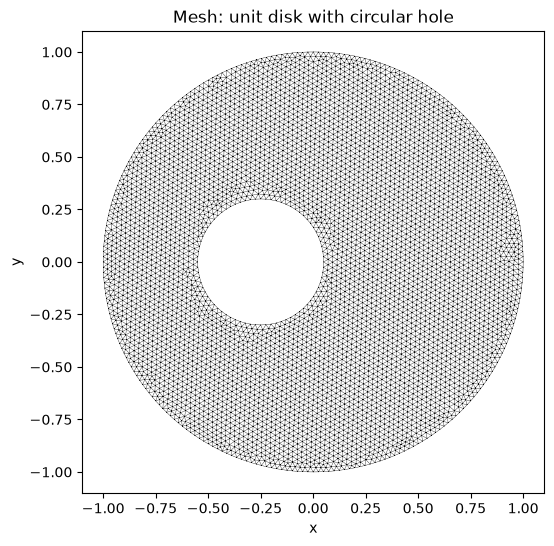

In [4]:
tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, 0)

cells = domain.topology.connectivity(tdim, 0).array.reshape(-1, 3)
points = domain.geometry.x[:, :2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.triplot(points[:, 0], points[:, 1], cells, color="black", linewidth=0.25)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Mesh: unit disk with circular hole")
plt.show()
plt.close(fig)


In [5]:
# ----------------------------------------------------------------------
# 3. P1 function space and diffusion tensor
# ----------------------------------------------------------------------
V = fem.functionspace(domain, ("Lagrange", 1))

D = ufl.as_matrix(((a1, 0.0), (0.0, a2)))
print(f"Number of P1 degrees of freedom: {V.dofmap.index_map.size_global}")


Number of P1 degrees of freedom: 5564


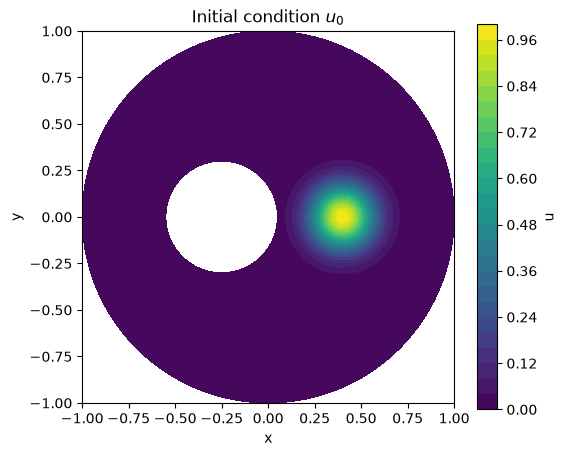

In [6]:
# ----------------------------------------------------------------------
# 4. Initial condition
# ----------------------------------------------------------------------
def u0_expr(x):
    distance_squared = (x[0] - x0) ** 2 + (x[1] - y0) ** 2
    return A0 * np.exp(-distance_squared / (2.0 * sigma0**2))

u_n = fem.Function(V, name="u")
u_n.interpolate(u0_expr)

uh = fem.Function(V, name="u")
uh.x.array[:] = u_n.x.array
uh.x.scatter_forward()

plot_solution(u_n, V, "Initial condition $u_0$")


In [7]:
# ----------------------------------------------------------------------
# 5. Lumped-mass IMEX Euler system
# ----------------------------------------------------------------------
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Row-sum lumping: m_i = integral(phi_i) = sum_j M_ij.
mass_weights_form = fem.form(v * ufl.dx)
m_lumped = create_vector(V)
with m_lumped.localForm() as local_mass:
    local_mass.set(0.0)
assemble_vector(m_lumped, mass_weights_form)
m_lumped.ghostUpdate(
    addv=PETSc.InsertMode.ADD,
    mode=PETSc.ScatterMode.REVERSE,
)

num_owned_dofs = V.dofmap.index_map.size_local * V.dofmap.index_map_bs
local_min_mass = np.min(m_lumped.array[:num_owned_dofs])
min_mass = domain.comm.allreduce(local_min_mass, op=MPI.MIN)
if min_mass <= 0.0:
    raise RuntimeError(f"Non-positive lumped mass detected: {min_mass}")
print(f"Smallest lumped mass: {min_mass:.6e}")

# A = M_L + dt K. The homogeneous Neumann condition is natural.
diffusion_form = fem.form(
    dt * ufl.inner(ufl.dot(D, ufl.grad(u)), ufl.grad(v)) * ufl.dx
)
A = assemble_matrix(diffusion_form)
A.assemble()
A.setDiagonal(m_lumped, PETSc.InsertMode.ADD_VALUES)
A.assemble()

b = create_vector(V)
explicit_state = fem.Function(V)


Smallest lumped mass: 1.797390e-04


In [8]:
# ----------------------------------------------------------------------
# 6. Reusable linear solver
# ----------------------------------------------------------------------
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(A)
solver.setType(PETSc.KSP.Type.PREONLY)
solver.getPC().setType(PETSc.PC.Type.LU)


In [9]:
track_points = np.array([[0.25, 0.25, 0.0],
                        [0.0,0.5,0.0],
                        [-0.25,0.5,0.0],
                        [-0.5,0.25,0.0],
                        [-0.75,0.0,0.0]],
                dtype=domain.geometry.x.dtype)
track_points_labels = ['(0.25, 0.25)', '(0.0, 0.5)', '(-0.25, 0.5)', '(-0.5, 0.25)', '(-0.75, 0.0)']
observations = np.zeros((num_steps, track_points.shape[0]))

In [10]:
# ----------------------------------------------------------------------
# 7. Time stepping
# ----------------------------------------------------------------------
for n in range(num_steps):
    # Explicit Nagumo reaction: r(u^n) = u^n (u^n-alpha) (u^n-1).
    u_values = u_n.x.array
    reaction_values = u_values * (u_values - alpha) * (u_values - 1.0)
    explicit_state.x.array[:] = u_values - dt * reaction_values
    explicit_state.x.scatter_forward()

    # b = M_L (u^n - dt r(u^n)).
    b.pointwiseMult(m_lumped, explicit_state.x.petsc_vec)

    # Solve (M_L + dt K) u^{n+1} = b.
    solver.solve(b, uh.x.petsc_vec)
    uh.x.scatter_forward()

    local_values = uh.x.array[:num_owned_dofs]
    local_finite = bool(np.all(np.isfinite(local_values)))
    if not domain.comm.allreduce(local_finite, op=MPI.LAND):
        raise FloatingPointError(f"Non-finite solution at step {n + 1}")

    step = n + 1
    if step == 1 or step % 50 == 0:
        u_min = domain.comm.allreduce(np.min(local_values), op=MPI.MIN)
        u_max = domain.comm.allreduce(np.max(local_values), op=MPI.MAX)
        if domain.comm.rank == 0:
            print(
                f"step {step:4d}/{num_steps}  t = {step * dt:5.2f}"
                f"  min(u) = {u_min:.6e}  max(u) = {u_max:.6e}"
            )

    u_n.x.array[:] = uh.x.array
    u_n.x.scatter_forward()
    #############################################################
    tree = geometry.bb_tree(domain, domain.topology.dim)

    candidates = geometry.compute_collisions_points(tree, track_points)

    colliding_cells = geometry.compute_colliding_cells(
        domain, candidates, track_points
    )
    track_point_cells = np.full(len(track_points), -1, dtype=np.int32)
    for i in range(len(track_points)):
        cells = colliding_cells.links(i)
        if len(cells) > 0:
            track_point_cells[i] = cells[0]
    #
    uh_obs = uh.eval(track_points, track_point_cells).squeeze()
    observations[n, :] = uh_obs
    #############################################################

final_time = num_steps * dt
print(f"Finished at t = {final_time:.2f}")


step    1/1000  t =  0.01  min(u) = 1.002813e-10  max(u) = 7.266771e-01
step   50/1000  t =  0.25  min(u) = 3.164368e-03  max(u) = 6.406891e-02
step  100/1000  t =  0.50  min(u) = 1.080901e-02  max(u) = 4.676027e-02
step  150/1000  t =  0.75  min(u) = 1.669279e-02  max(u) = 3.768433e-02
step  200/1000  t =  1.00  min(u) = 2.022141e-02  max(u) = 3.248095e-02
step  250/1000  t =  1.25  min(u) = 2.197596e-02  max(u) = 2.913346e-02
step  300/1000  t =  1.50  min(u) = 2.260379e-02  max(u) = 2.678043e-02
step  350/1000  t =  1.75  min(u) = 2.256354e-02  max(u) = 2.499943e-02
step  400/1000  t =  2.00  min(u) = 2.214216e-02  max(u) = 2.356205e-02
step  450/1000  t =  2.25  min(u) = 2.151153e-02  max(u) = 2.233874e-02
step  500/1000  t =  2.50  min(u) = 2.077279e-02  max(u) = 2.125446e-02
step  550/1000  t =  2.75  min(u) = 1.998492e-02  max(u) = 2.026524e-02
step  600/1000  t =  3.00  min(u) = 1.918202e-02  max(u) = 1.934509e-02
step  650/1000  t =  3.25  min(u) = 1.838368e-02  max(u) = 1.847

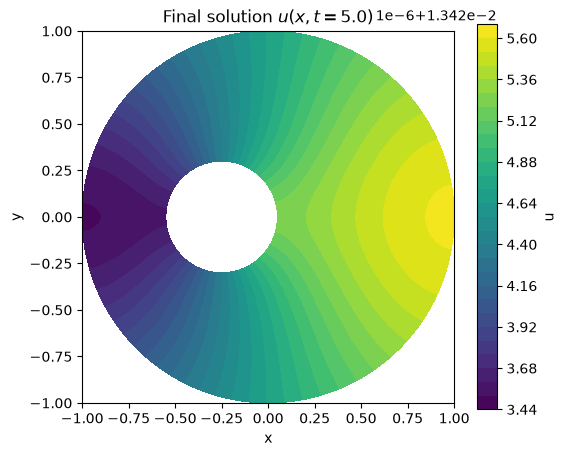

In [11]:
# ----------------------------------------------------------------------
# 8. Final solution
# ----------------------------------------------------------------------
plot_solution(uh, V, f"Final solution $u(x, t={T})$")


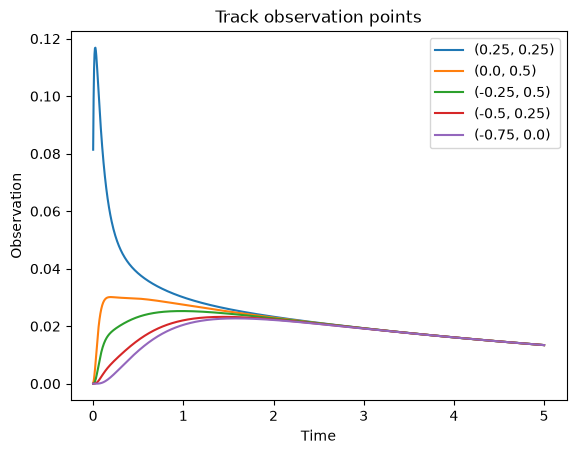

In [12]:
for n in range(track_points.shape[0]):
    plt.plot(np.linspace(0.0, T, num_steps), observations[:,n], label=track_points_labels[n])
plt.legend()
plt.xlabel("Time")
plt.ylabel("Observation")
plt.title("Track observation points")
plt.show()